# Trabajo Práctico Integrador - Módulo Python

**Maestría en Econometría — Universidad Torcuato Di Tella**  

Alumna: María Belén Paisan

Segundo Trimestre 2026

---


Carga de paquetes a utilizar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
import statsmodels.api as sm

Semilla a utilizar

In [2]:
np.random.seed(43)

---
## PARTE 1 - Robustez ante contaminación de muestras

### 1.1 Estimadores de tendencia central

Para este punto, primero se determinarán los parámetros a utilizar para una muestra base y una muestra contaminada. Luego, se definirán las funciones necesarias para el cálculo del sesgo y el error cuadrático medio (ECM). Por último, se realizarán las simulaciones y los gráficos requeridos para el análisis

Para este caso, la contaminación se representó mediante observaciones generadas de una distribución con media y desvíos mayores.

In [3]:
# ── Parámetros ────────────────────────────────────────────────────────────────

# Parámetros base
n = 100   # Tamaño de muestra
M = 1000    # Cantidad de simulaciones
mu_0 = 2
sigma_0 = 1

# Parámetros de contaminación
porcentajes = [0, 0.05, 0.10, 0.20]   # Porcentajes de contaminación
mu_c = 6
sigma_c = 4

In [4]:
# ── Funciones ─────────────────────────────────────────────────────────────────

# Sesgo
def calculo_sesgo(vector_m, mu_verdadero):
    """
    Calcula el sesgo de la media o mediana muestral.

    El vector de las medias/medianas muestrales debe ser provisto por el usuario
    (vector_m), junto con el verdadero valor poblacional (mu_verdadero).

    Primero se calcula la aproximación muestral de la esperanza con el promedio
    de las medias/medianas y luego se le resta el valor verdadero de mu.

    La función devuelve el valor del sesgo.
    """
    esperanza  = vector_m.mean()
    sesgo      = esperanza - mu_verdadero
    return sesgo

# Error cuadrático medio (ECM)
def calculo_ecm(vector_m, sesgo):
    """
    Calcula el error cuadrático medio (ecm) de la media o mediana muestral.

    El vector de medias/medianas debe ser provisto por el usuario (vector_m),
    al igual que el sesgo (sesgo).

    Primero se calcula la varianza empírica de las medias/medianas y luego se la
    utiliza, junto con el sesgo provisto, para calcular el ecm.

    La función devuelve el valor del ecm.
    """
    var_emp    = vector_m.var(ddof=1)
    ecm        = sesgo**2 + var_emp
    return ecm

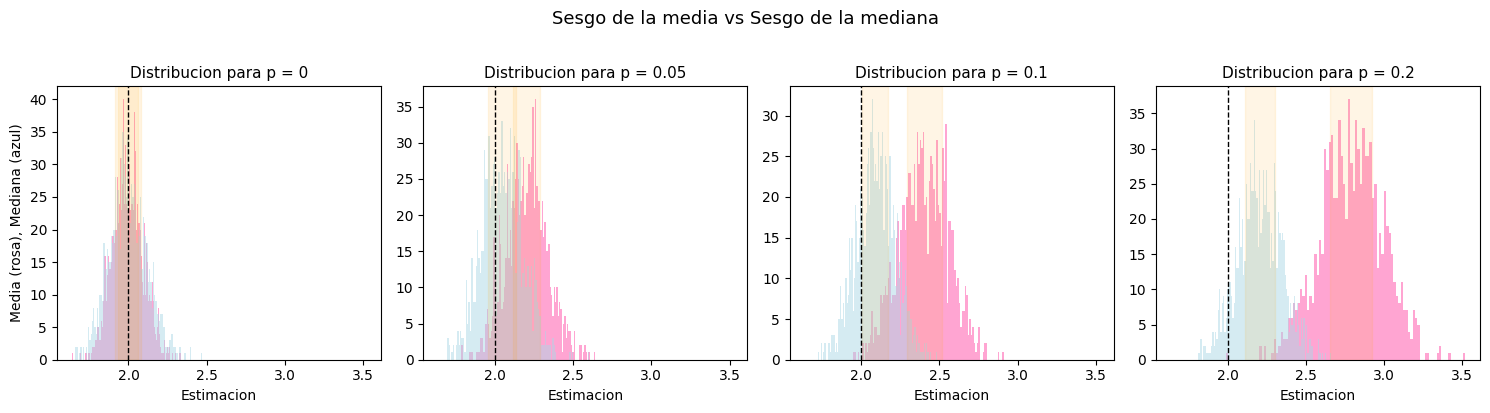

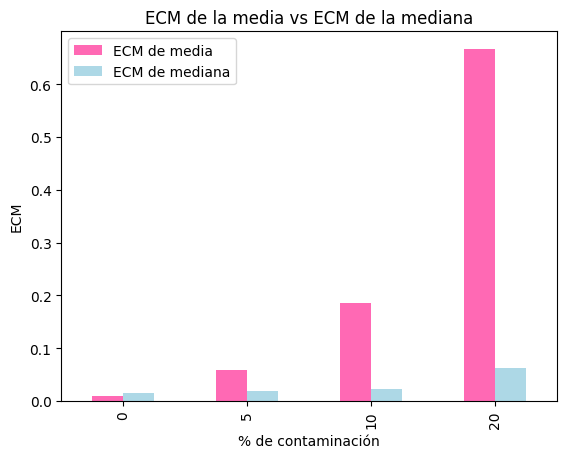

Porcentaje de contaminación,Sesgo de media,ECM de media,Sesgo de mediana,ECM de mediana
0,-0.0032,0.0096,-0.0010,0.0150
5,0.2030,0.0583,0.0491,0.0192
10,0.4015,0.1853,0.0916,0.0237
20,0.7913,0.6665,0.2039,0.0618


In [5]:
# ── Simulaciones ──────────────────────────────────────────────────────────────

# Creación de lista para guardar resultados de cada contaminación
resultados = []

# Configuración de grilla y tamaño para los gráficos
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True)

# Loop para los distintos porcentajes de contaminación (y gráficos)
for p, ax in zip(porcentajes, axes):

  # Creación de listas para guardar resultados de cada simulación
  medias = []
  medianas = []

  # Loop para simulaciones de muestras
  for i in range(M):

    # Generación de muestras base y contaminadas
    muestra_base = np.random.normal(mu_0, sigma_0, size=n)
    muestra_c = np.random.normal(mu_c, sigma_c, size=n)

    #Contaminación
    # Generación de ids aleatorios
    id = np.random.permutation(n)
    # Cantidad de observaciones a contaminar
    n_c = int(p * n)
    # Selección de ids para contaminación y para base
    id_c, id_base = id[:n_c], id[n_c:]
    muestra_base = muestra_base[id_base]
    muestra_c = muestra_c[id_c]
    # Agrupación de ambas en una sola muestra
    muestra = np.concatenate((muestra_base, muestra_c))

    # Guardado de la media y mediana estimada
    medias.append(np.mean(muestra))
    medianas.append(np.median(muestra))

  # Transformación en array
  medias = np.array(medias)
  medianas = np.array(medianas)

  # Cálculo de sesgo y ecm
  sesgo_media = calculo_sesgo(medias, mu_0)
  ecm_media = calculo_ecm(medias, sesgo_media)
  sesgo_mediana = calculo_sesgo(medianas, mu_0)
  ecm_mediana = calculo_ecm(medianas, sesgo_mediana)

  # Guardado de resultados
  resultados.append({
            'Porcentaje de contaminación': round(p*100, ),
            'Sesgo de media':     round(sesgo_media, 4),
            'ECM de media':     round(ecm_media, 4),
            'Sesgo de mediana':     round(sesgo_mediana,   4),
            'ECM de mediana':      round(ecm_mediana,   4)
        })

  # Generación de histogramas para medias/medianas para cada porcentaje de cont.
  ax.hist(medias,   bins=100, alpha=0.6, density=False, color='hotpink')
  ax.hist(medianas, bins=100, alpha=0.5, density=False, color='lightblue')
  # Generación de recta en valor verdadero poblacional
  ax.axvline(mu_0, color='black', linewidth=1, linestyle='--')
  # Generación de percentiles
  p25_medias = np.percentile(medias, 25)
  p75_medias = np.percentile(medias, 75)
  p25_medianas = np.percentile(medianas, 25)
  p75_medianas = np.percentile(medianas, 75)
  # Generación de area intercuantil
  ax.axvspan(p25_medias, p75_medias, color="orange", alpha=0.1)
  ax.axvspan(p25_medianas, p75_medianas, color="orange", alpha=0.1)
  # Títulos
  ax.set_title(f'Distribucion para p = {p}', fontsize=11)
  ax.set_xlabel('Estimacion')

axes[0].set_ylabel('Media (rosa), Mediana (azul)')
fig.suptitle('Sesgo de la media vs Sesgo de la mediana', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Transformación de resultados en data set
resultados_df = pd.DataFrame(resultados)
# Gráfico de comparación de ECM
resultados_df.plot(x='Porcentaje de contaminación', y=['ECM de media', 'ECM de mediana'],
                   kind='bar', color=["hotpink", "lightblue"])
plt.title('ECM de la media vs ECM de la mediana')
plt.xlabel('% de contaminación')
plt.ylabel('ECM')
plt.show()
# Exposición de resultados numéricos
resultados_df.style.hide(axis="index").format(precision=4)

Se puede observar que en el caso base, donde la contaminación es cero, tanto la distribución de la media muestral como la de la mediana muestral se encuentran centradas en el verdadero valor del parámetro (2). En ese caso, el ECM de la mediana es ligeramente superior, dejando a la media muestral como el mejor estimador.

Sin embargo, a medida que aumenta el porcentaje de contaminación de la muestra, la distribución de la media muestral deja de estar centrada en el verdadero valor y pasa a centrarse en valores más grandes. Esto se debe a que la mayor presencia de observaciones contaminadas que, en este caso, se originaron de una distribución con media más grande (6). Esto genera un sesgo positivo de la media muestral inmediatamente visible. En el caso extremo, con un porcentaje de contaminación del 20%, pareciera que ni siquiera una de las estimaciones de la media muestral toma el valor de 2.

Se puede observar, incluso, que el ECM de la mediana ya es menor que el de la media para un 5% de muestra contaminada. Esto es causado tanto por el sesgo mencionado anteriormente como por un aumento en la varianza de la distribución. Otra vez observando el caso extremo, la cantidad de estimaciones fuera del rango intercuantil (fuera del área naranja) es mucho más grande que para el caso base, evidenciandose así el aumento en la varianza de las estimaciones.

Cabe mencionar también que si bien pareciera que la mediana muestral es un mejor estimador bajo la sospecha de muestras contaminadas, eventualmente esta también empieza a sesgarse y a aumentar su ECM.

### 1.2 Regresión lineal bajo contaminación

Al igual que en el punto anterior, primero se determinarán los parámetros a utilizar en la generación de la variable $Y$ base. Luego, se definirán las funciones necesarias para la estimación a mano mediante OLS y mediante LAD (Least Absolute Deviation). Por último, se realizarán las simulaciones junto con la contaminación y los gráficos requeridos para el análisis. También se generará un gráfico adicional de los modelos estimados para cada porcentaje de contaminación.


En cuanto a la contaminación, se intentó representar una situación en la que algunas personas no dicen la verdad al contestar encuestas. Por ejemplo, si la variable $Y$ fuera "Ingresos" y la variable $X$ fuera "Horas trabajadas", puede ocurrir que las personas subdeclaren sus ingresos y exageren sus horas trabajadas. Tratando de replicar esta situación, en la celda de Simulaciones, para observaciones aleatorias, se multiplicó su variable $Y$ por un porcentaje aleatorio (entre 20 y 90%) para generar un valor menor al "original" y se le sumó a su variable $X$ un número aleatorio (entre 8 y 48).

In [6]:
# ── Parámetros ────────────────────────────────────────────────────────────────

# Parámetros base
n = 100   # Tamaño de muestra
M = 500    # Cantidad de simulaciones

# Parámetros del modelo
beta0 = 5
beta1 = 2
sigma = 1

# Parámetros de contaminación
porcentajes = [0, 0.05, 0.10, 0.20]   # Porcentajes de contaminación

In [7]:
# ── Funciones ─────────────────────────────────────────────────────────────────

# Estimación OLS

def estimacion_ols(y, x, n):
  """
  Realiza "a mano" la estimación OLS mediante la fórmula matricial.

  El usuario debe proveer el vector de variables dependientes (y) junto
  con el vector de regresores (x) y el tamaño de la muestra (n).

  Primero, se genera la matriz X, adicionando una columna de constantes a los
  regresores provistos por el usuario. Luego se estiman los coeficientes
  mediante la función np.linalg.solve. Por último, se calculan la cantidad de
  coeficientes a guardar.

  La función devuelve un diccionario con los valores estimados de los
  coeficientes.
  """
  X = np.column_stack([np.ones(n), x])
  coeficientes = np.linalg.solve(X.T @ X, X.T @ y)
  cantidad_coeficientes = X.shape[1]

  betas_ols = { f'beta_{i}': coeficientes[i] for i in range(cantidad_coeficientes) }
  return betas_ols

# Estimación LAD

def estimacion_LAD(y, x, n):
    """
    Realiza la estimación del modelo mediante la minimización de la sumatoria
    de errores absolutos.

    El usuario debe proveer el vector de variables dependientes (y) junto
    con el vector de regresores (x) y el tamaño de la muestra (n).

    Primero, se genera la matriz X, adicionando una columna de constantes a los
    regresores provistos por el usuario. Luego, se calculan la cantidad de
    coeficientes a guardar y se establecen los valores iniciales de los betas
    como ceros. Utilizando las funciones LAD y residuos (definidas abajo) se
    minimizan los suma de los residuos absolutos mediante optimize.minimize y
    se guardan los betas óptimos encontrados en coeficientes.

    La función devuelve un diccionario con los valores estimados de los
    coeficientes.
    """
    X = np.column_stack([np.ones(n), x])
    cantidad_coeficientes = X.shape[1]
    beta_init = np.zeros(cantidad_coeficientes)

    def LAD(e):
      """
      Es la función a aplicar a los residuos, la sumatoria de su valor
      absoluto

      El usuario (u otra función) debe proveer el vector de residuos (e).

      Primero, se calcula el valor absoluto de los residuos y después se suman.

      La función devuelve el resultado de la suma.
      """
      return np.sum(np.abs(e))


    def residuos(beta):
      """
      Genera los residuos de una estimación y aplica la función LAD definida
      anteriormente para obtener el objeto a minimizar.

      El usuario (o el optimizador) debe proveer el beta a utilizar (beta).

      Primero, se calcula el valor de los residuos como la diferencia
      entre el valor original y su estimacion (X @ beta) y luego la función
      devuelve la sumatoria de los valores absolutos de los residuos.
      """
      res = y - X @ beta
      return LAD(res)

    minimizacion = optimize.minimize(residuos, beta_init, method='Nelder-Mead',
                                  options={'maxiter': 10000, 'xatol': 1e-8})
    coeficientes = minimizacion.x

    betas_LAD = { f'beta_{i}': coeficientes[i] for i in range(cantidad_coeficientes) }

    return betas_LAD


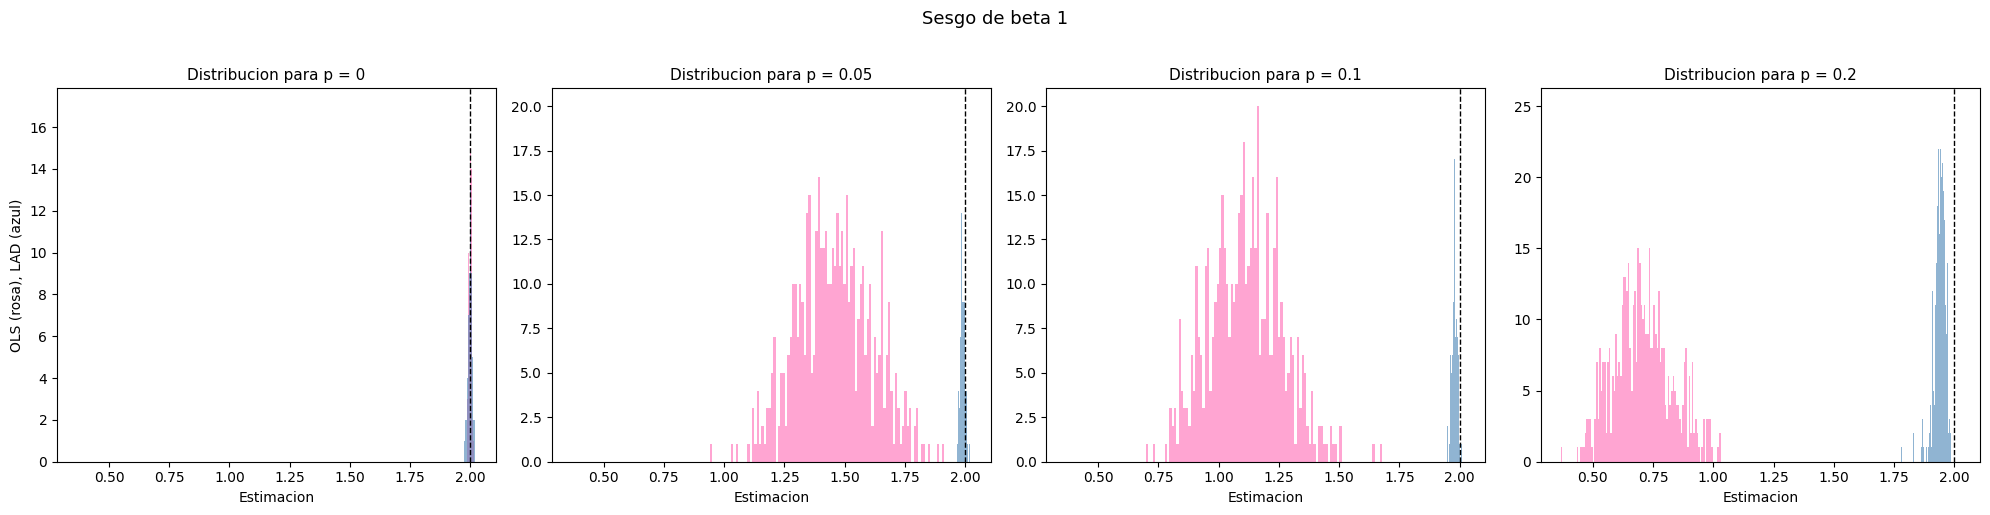

Porcentaje de contaminación,Sesgo de beta 1 en OLS,ECM de beta 1 en OLS,Sesgo de beta 1 en LAD,ECM de beta 1 en LAD
0,-0.0002,0.0000,-0.0002,0.0001
5,-0.5416,0.3183,-0.0108,0.0002
10,-0.8903,0.8160,-0.0216,0.0006
20,-1.2932,1.6872,-0.0624,0.0046


In [8]:
# ── Simulaciones ──────────────────────────────────────────────────────────────

# Creación de lista para guardar resultados de cada modelo y contaminación
medias_beta1_OLS = []
medias_beta0_OLS = []
medias_beta1_LAD = []
medias_beta0_LAD = []
resultados = []
# Creación de lista para guardar datos de X e Y de la última simulacion corrida
# para cada porcentaje de contaminación para generar gráficos.
datos = []

# Configuración de grilla y tamaño para los gráficos
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)

# Loop para distintos porcentajes de contaminación (y gráficos)
for p, ax in zip(porcentajes, axes):

  # Creación de listas para guardar resultados de cada simulación
  beta_ceros_OLS = []
  beta_unos_OLS = []
  beta_ceros_LAD = []
  beta_unos_LAD = []

  # Loop para simulaciones de muestras
  for i in range(M):

    # Las variables X se generan como realizaciones de una uniforme entre 0 y 48
    X_base = np.random.uniform(0, 48, size=n)

    # El error epsilon tiene una distribución normal con media 0 y desvío sigma
    epsilon_base = np.random.normal(0, sigma, size=n)

    # Modelo verdadero: y = beta0 + beta1 * X + epsilon
    Y = beta0 + beta1 * X_base + epsilon_base

    # Contaminación
    # Cantidad de observaciones a contaminar
    n_c = int(n * p)
    # Selección aleatoria de ids contaminados
    id_c = np.random.choice(n, n_c, replace=False)
    # Generación de Y e X contaminado
    Y_c = Y.copy()
    X_c = X_base.copy()
    # Loop para cada observacion contaminada
    for r in id_c:
      # Generación de error de medición
      error_x = np.random.uniform(8, 48)
      error_y = np.random.uniform(0.2, 0.9)
      # Reemplazo por observacion contaminada
      X_c[r] = X_c[r] + error_x
      Y_c[r] = Y_c[r]*error_y

    # Guardado de ultimos datos para gráficos
    if i == M-1:
      datos_X = X_c
      datos_Y = Y_c
      datos_id = id_c
      datos.append({
            'Porcentaje de contaminación': round(p*100, ),
            'X': datos_X,
            'Y': datos_Y,
            'X contaminados': datos_X[id_c],
            'Y contaminados': datos_Y[id_c],
            })

    # Estimación OLS
    resultado_OLS = estimacion_ols(Y_c, X_c, n)
    # Guardado de coeficientes
    beta_ceros_OLS.append(resultado_OLS["beta_0"])
    beta_unos_OLS.append(resultado_OLS["beta_1"])

    # Estimación LAD
    resultado_LAD = estimacion_LAD(Y_c, X_c, n)
    # Guardado de coeficientes
    beta_ceros_LAD.append(resultado_LAD["beta_0"])
    beta_unos_LAD.append(resultado_LAD["beta_1"])

  # Guardado de la media de las simulaciones de cada coeficiente
  medias_beta0_OLS.append(np.mean(beta_ceros_OLS))
  medias_beta1_OLS.append(np.mean(beta_unos_OLS))
  medias_beta0_LAD.append(np.mean(beta_ceros_LAD))
  medias_beta1_LAD.append(np.mean(beta_unos_LAD))
  # Transformación en array
  beta_unos_OLS = np.array(beta_unos_OLS)
  beta_unos_LAD = np.array(beta_unos_LAD)

  # Calculo de sesgo y ECM
  sesgo_beta1_OLS = calculo_sesgo(beta_unos_OLS, beta1)
  ecm_beta1_OLS = calculo_ecm(beta_unos_OLS, sesgo_beta1_OLS)
  sesgo_beta1_LAD = calculo_sesgo(beta_unos_LAD, beta1)
  ecm_beta1_LAD = calculo_ecm(beta_unos_LAD, sesgo_beta1_LAD)

  # Guardado de resultados
  resultados.append({
            'Porcentaje de contaminación': round(p*100, ),
            'Sesgo de beta 1 en OLS':     round(sesgo_beta1_OLS, 4),
            'ECM de beta 1 en OLS':     round(ecm_beta1_OLS, 4),
            'Sesgo de beta 1 en LAD':     round(sesgo_beta1_LAD, 4),
            'ECM de beta 1 en LAD':     round(ecm_beta1_LAD, 4),
        })

  # Generación de histogramas de ambos métodos para cada porcentaje de cont.
  ax.hist(beta_unos_OLS,   bins=100, alpha=0.6, density=False, color='hotpink')
  ax.hist(beta_unos_LAD,   bins=100, alpha=0.6, density=False, color='steelblue')
  #  Generación de recta en valor verdadero poblacional
  ax.axvline(beta1, color='black', linewidth=1, linestyle='--')
  # Títulos
  ax.set_title(f'Distribucion para p = {p}', fontsize=11)
  ax.set_xlabel('Estimacion')

axes[0].set_ylabel('OLS (rosa), LAD (azul)')
fig.suptitle('Sesgo de beta 1', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Transformación en resultados en data set
resultados_df = pd.DataFrame(resultados)
# Exposición de resultados numéricos
resultados_df.style.hide(axis="index").format(precision=4)


Al igual que en el punto anterior, en el caso base sin contaminación los dos estimadores coinciden en estar centrados en el verdadero valor del parámetro (2). Incluso el sesgo y ECM toma el mismo valor para ambos.

Sin embargo, solamente con un porcentaje de contaminación del 5% la estimación LAD se comporta mejor que OLS, con un sesgo y ECM menores. En el gráfico se puede ver que con este pequeño porcentaje de contaminación la distribución del coeficiente $\beta_1$ estimado por OLS está totalmente desplazada hacia un valor más pequeño, subetimando el valor del parámetro.

Esto se debe a que, como fue visto en clase, el método OLS, al minimzar los residuos al cuadrado, potencia la magnitud de las diferencias entre el valor estimado de la variable $Y$ y su valor verdadero. Por otro lado, LAD, al minimizar la suma de los valores absolutos de los residuos, tiene en cuenta esta diferencia pero no amplifica su magnitud.

Es por esto que, frente a la sospecha de muestras contaminadas, la estimación de LAD puede ser una mejor herramienta, ya que no ponderará al cuadrado los residuos de las observaciones atípicas.

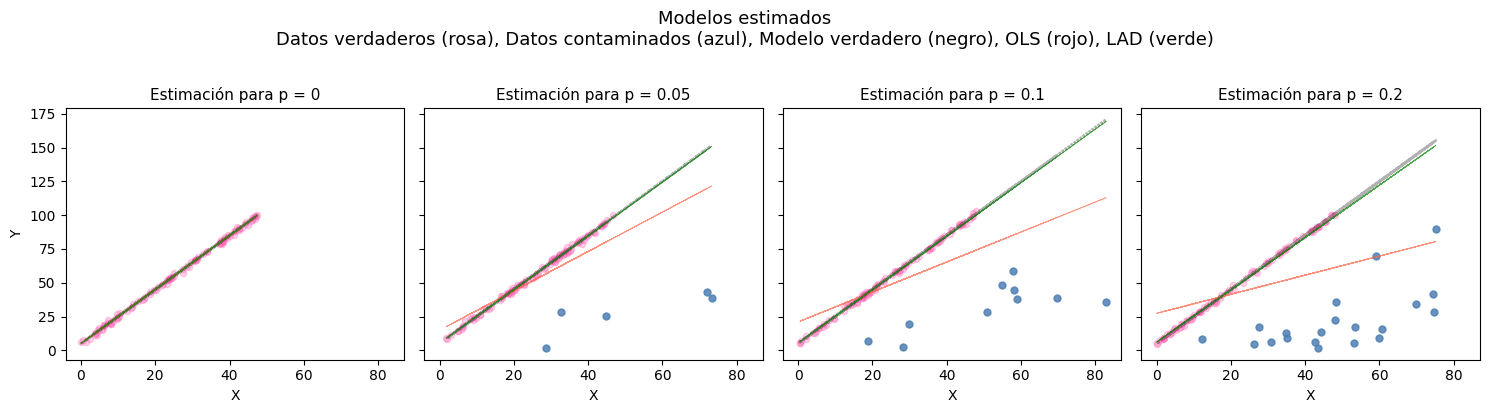

In [9]:
# ── Gráfico adicional ─────────────────────────────────────────────────────────

# Transformación en dataframe de los datos de X e Y de la última simulación de
# cada porcentaje de contaminación y de las medias de cada coeficiente.
datos_df = pd.DataFrame(datos)
medias0OLS_df=pd.DataFrame(medias_beta0_OLS)
medias1OLS_df=pd.DataFrame(medias_beta1_OLS)
medias0LAD_df=pd.DataFrame(medias_beta0_LAD)
medias1LAD_df=pd.DataFrame(medias_beta1_LAD)

# Configuración de grilla y tamaño para los gráficos
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True, sharex=True)
cantidad_graficos = [0,1,2,3]

# Loop para generar los gráficos para cada porcentaje de contaminación
for ax, c, p in zip(axes,cantidad_graficos, porcentajes):
  # Generación de scatterplot para datos base
  ax.scatter(datos_df.iloc[c,1], datos_df.iloc[c,2], alpha=0.3, color='hotpink', s=20)
  # Superposición de scatterplot para datos contaminados
  ax.scatter(datos_df.iloc[c,3], datos_df.iloc[c,4], alpha=0.8, color='steelblue', s=25)
  # Generación de recta de regresión para modelo original
  ax.plot(datos_df.iloc[c,1], beta0 + beta1*datos_df.iloc[c,1],
          alpha=0.3, color='black', linewidth=2, linestyle=':')
  #  Generación de recta de regresión para modelo OLS
  ax.plot(datos_df.iloc[c,1], medias0OLS_df.iloc[c,0] + medias1OLS_df.iloc[c,0]*datos_df.iloc[c,1],
          alpha=0.7, color='tomato', linewidth=0.5)
  #  Generación de recta de regresión para modelo LAD
  ax.plot(datos_df.iloc[c,1], medias0LAD_df.iloc[c,0] + medias1LAD_df.iloc[c,0]*datos_df.iloc[c,1],
          alpha=0.7, color='green', linewidth=0.5)
  # Títulos
  ax.set_title(f'Estimación para p = {p}', fontsize=11)
  ax.set_xlabel('X')

axes[0].set_ylabel('Y')
fig.suptitle('Modelos estimados\nDatos verdaderos (rosa), Datos contaminados (azul), Modelo verdadero (negro), OLS (rojo), LAD (verde)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



En estos gráficos se presentan las observaciones obtenidas de la última muestra simulada para cada porcentaje de contaminación, como ejemplo. Se puede observar que en el caso base las 3 rectas de regresión (la del modelo base, la de la estimación OLS y la de la estimación LAD) se encuentran perfectamente sobre la recta que forman datos verdaderos (a tal punto que no se pueden distinguir las rectas).

A medida que empiezan a aparecer los datos de contaminación (los puntos azules), la recta roja de OLS empieza a inclinarse hacia ellos, cada vez más. Esto es debido a lo mencionado anteriormente acerca de la ponderación elevada de los valores atípicos. Mientras tanto, al recta de LAD sigue confundiéndose con el modelo verdadero, demostrando que es una buena estimación para esta muestra particular. Sólo en el casó de contaminación más extremo se puede ver una ligera diferencia con el modelo verdadero.

## Conclusión PARTE 1:

En esta primera parte se pudo observar que, si bien en general el uso de la media muestral como estimador de la media y de OLS como método de estimación de la regresión lineal es lo recomendable por sus propiedades estadísticas (insesgadez, eficiencia, etc.), los valores atípicos pueden dañar su funcionamiento. En esta situación, la mediana muestral y el estimador LAD pueden ser buenas alternativas.

De esto también se puede concluir que siempre es útil realizar un análisis exploratorio inicial (visual si las dimensiones lo permiten) para detectar observaciones atípicas y decidir la mejor estrategia a seguir.

---
## PARTE 2 - Paradoja de Simpson y variables omitidas

### 2.1 Construcción del modelo

Al igual que en la primera parte, primero se definirán los parámetros base para el ejercicio. Luego, se realizarán las simulaciones para distintos tamaños de muestra y se mostrará la media y desvío de cada distribución del parámetro $\beta_x$.

En cuanto al sesgo correspondiente a cada variable omitida, si $Y$ y $X$ son independientes pero la regresión condicional $Y \sim X+W$ muestra un $\beta_x$ positivo, hay algo en el error ($Z$) que está generando un sesgo positivo. Para que se esté generando tal sesgo, $Z$ debe estar correlacionada positivamente con $X$ e $Y$: valores más grandes de $X$ e $Y$ deben estar correlacionados con valores mayores de $Z$. Por lo tanto, para generar esta correlación, se definió que cuanto más alto sea el resultado de $X + Y$ (relación positiva), mayor sería el nivel asignado de $Z$. Se utilizaron los cuantiles observados de $X$ para determinar los umbrales en los que se cambia entre niveles de $Z$. Para el caso de $W$, se realizó el mismo análisis pero con un sesgo negativo.

In [10]:
# ── Parámetros ────────────────────────────────────────────────────────────────

# Parámetros base
tamaños = [30, 100, 500]    # Tamaños de muestra
M = 1000   # Cantidad de simulaciones

# Parámetros para variable X
media_X = 0
sigma_X = 1
# Parámetros para variable Y
limite_inf_Y = -2
limite_sup_Y = 2

In [11]:
# ── Simulaciones ──────────────────────────────────────────────────────────────

# Creación de listas para guardar resultados para cada tamaño de muestra
medias_beta_sin = []
medias_beta_control_1 = []
medias_beta_control_2 = []
resultados = []
# Creación de lista para guardar datos de X e Y de la última simulacion corrida
# para cada tamaño de muestra para generar gráficos.
datos = []

# Loop para distintos tamaños de muestra
for n in tamaños:

  # Creación de listas para guardar resultados de cada simulación
  betas_sin =[]
  betas_control_1=[]
  betas_control_2=[]

  # Loop para simulaciones de muestras
  for m in range(M):

    # Generación de X como una Normal (media, sigma)
    X = np.random.normal(media_X, sigma_X, size=n)
    # Generación de Y como una Uniforme entre limite superior e inferior
    Y = np.random.uniform(limite_inf_Y, limite_sup_Y, size=n)

    # Generación de umbrales de X según cuantiles
    umbral_1 = np.percentile(X, [25, 50, 75])[0]
    umbral_2 = np.percentile(X, [25, 50, 75])[1]
    umbral_3 = np.percentile(X, [25, 50, 75])[2]
    # Generación de relaciones positivas y negativas para correlacionar
    relacion_positiva = X + Y
    relacion_negativa = X - Y

    # Generación de Z y W con ceros
    Z = np.zeros(n)
    W = np.zeros(n)

    # Loop para reemplazar valores de Z según correlación positiva
    for i in range(n):
      if relacion_positiva[i] < umbral_1:
        Z[i] = 1
      elif relacion_positiva[i] < umbral_2:
        Z[i] = 2
      elif relacion_positiva[i] < umbral_3:
        Z[i] = 3
      else:
        Z[i] = 4

    # Loop para reemplazar valores de W según correlación negativa
    for i in range(n):
      if relacion_negativa[i] < umbral_1:
        W[i] = 1
      elif relacion_negativa[i] < umbral_2:
        W[i] = 2
      elif relacion_negativa[i] < umbral_3:
        W[i] = 3
      else:
        W[i] = 4

    # Guardado de ultimos datos para gráficos
    if  m == M-1:
      datos_X = X
      datos_Y = Y
      datos_Z = Z
      datos_W = W
      datos.append({
            'Tamaño de muestra': n,
            'X': datos_X,
            'Y': datos_Y,
            'Z': datos_Z,
            'W': datos_W,
            })

    # Generación de matrices X para cada caso, junto con la constante
    X_sin = sm.add_constant(X)
    X_control_1 = sm.add_constant(np.column_stack([X, Z]))
    X_control_2 = sm.add_constant(np.column_stack([X, W]))

    # Estimación y guardado de beta_x del modelo sin controles
    modelo = sm.OLS(Y, X_sin).fit()
    betas_sin.append(modelo.params[1])

    # Estimación y guardado de beta_x del modelo con control 1 (Z)
    modelo1 = sm.OLS(Y, X_control_1).fit()
    betas_control_1.append(modelo1.params[1])

    # Estimación y guardado de beta_x del modelo con control 1 (W)
    modelo2 = sm.OLS(Y, X_control_2).fit()
    betas_control_2.append(modelo2.params[1])

  # Guardado de la media de las simulaciones de cada coeficiente
  medias_beta_sin.append(np.mean(betas_sin).round(2))
  medias_beta_control_1.append(np.mean(betas_control_1).round(2))
  medias_beta_control_2.append(np.mean(betas_control_2).round(2))
  # Guardado de resultados
  resultados.append({
            'Tamaño de muestra': n,
            'Media de beta sin controles':     np.mean(betas_sin).round(2),
            'Desvío de beta sin controles':     np.std(betas_sin),
            'Media de beta con control 1':     np.mean(betas_control_1).round(2),
            'Desvío de beta con control 1':     np.std(betas_control_1),
            'Media de beta con control 2':     np.mean(betas_control_2).round(2),
            'Desvío de beta con control 2':     np.std(betas_control_2),
        })

# Transformación de resultados en dataframe
resultados_df = pd.DataFrame(resultados)
# Exposición de resultados numéricos
resultados_df.style.hide(axis="index").format(precision=4)

Tamaño de muestra,Media de beta sin controles,Desvío de beta sin controles,Media de beta con control 1,Desvío de beta con control 1,Media de beta con control 2,Desvío de beta con control 2
30,-0.0000,0.2197,-0.6500,0.1567,0.6500,0.1623
100,-0.0000,0.1212,-0.6500,0.0902,0.6500,0.0894
500,-0.0000,0.0515,-0.6500,0.0385,0.6500,0.0399


Tal como se puede observar en la tabla, el sesgo por variables omitidas no desaparece para tamaños de muestra más grandes, sino que lo único que se logra es aumentar la precisión de la estimación.

El modelo sin controles ($Y \sim X$) muestra la verdad de la relación entre $Y$ y $X$: no hay tal relación ya que ambas fueron generadas independientemente, por lo que la media de la distribución de $\beta_x$ es 0.

En el modelo con control 1 ($Y \sim X + Z$), la inclusión de $Z$ al estimar el modelo pero no $W$ (que permanece en el error) hace que la media de la distribución de $\beta_x$ se encuentre en un valor negativo (-0.65). Este sesgo es el mismo para todo tamaño de muestra, pero el desvío sí disminuye, mejorando la precisión de la estimación.

En el modelo de control 2 ($Y \sim X + W$), sucede lo mismo pero con un valor positivo del sesgo (0.65), el cual es el mismo que el anterior en términos absolutos ya que las variables $Z$ y $W$ fueron definidas con los mismos umbrales.

---
### 2.2 Ilustración de la paradoja

Para ilustrar la paradoja, se optó por utilizar los datos guardados de las simulaciones anteriores. De cada una de las 1000 simulaciones para cada tamaño de muestra se guardó la última simulacion de las variables $X$, $Y$, $Z$ y $W$ como ejemplo y se generaron scatterplots diferenciados para analizar lo que está interpretando cada modelo al estimar la esperanza condicional de $Y$.

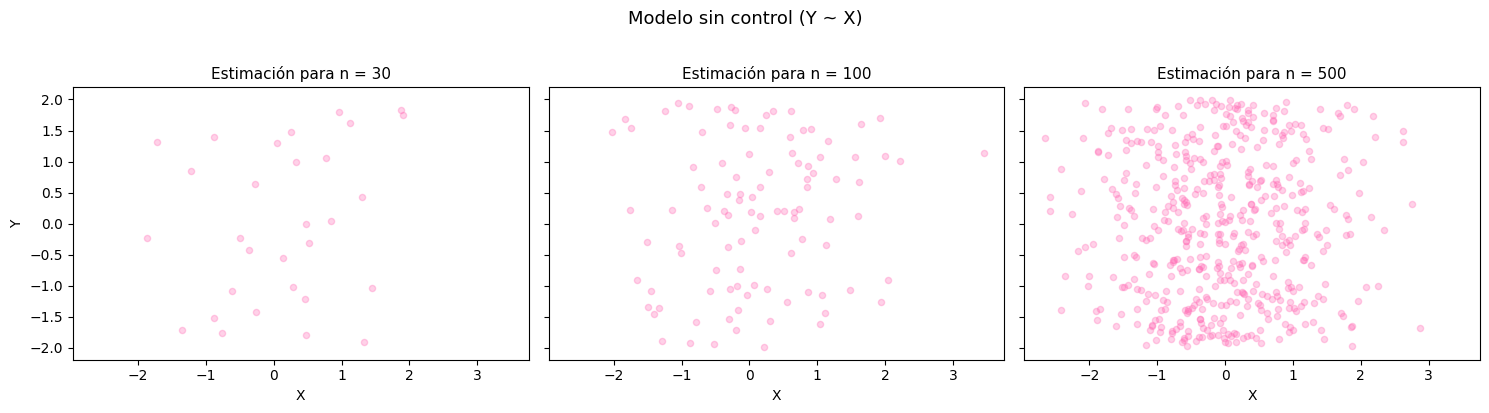

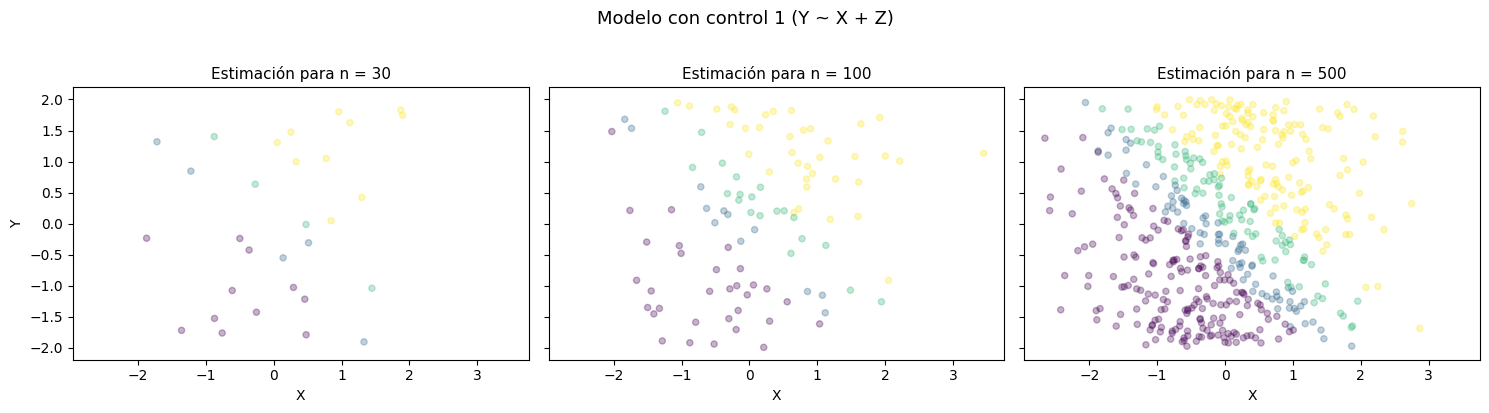

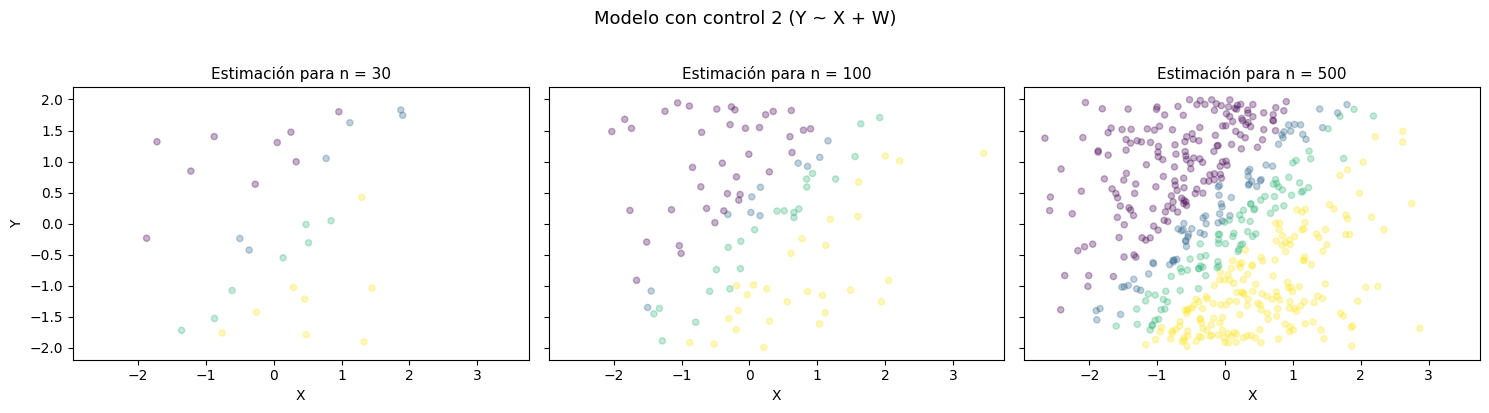

In [12]:
# ── Ilustración ───────────────────────────────────────────────────────────────

# Transformación de datos en dataframe
datos_df = pd.DataFrame(datos)

# ----------- Modelo sin control (Y ~ X) ---------------------------------------

# Configuración de grilla y tamaño para los gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, sharex=True)
cantidad_graficos = [0,1,2]

# Loop para generar los gráficos para cada tamaño de muestra
for ax, c, n in zip(axes,cantidad_graficos, tamaños):
  # Generación de scatterplot
  ax.scatter(datos_df.iloc[c,1], datos_df.iloc[c,2], alpha=0.3, c="hotpink", s=20)
  # Títulos
  ax.set_title(f'Estimación para n = {n}', fontsize=11)
  ax.set_xlabel('X')

axes[0].set_ylabel('Y')
fig.suptitle('Modelo sin control (Y ~ X)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Para los otros dos modelos se repite el gráfico anterior con los datos
# correspondientes y agregando que los puntos se pintan según Z o W.

# ----------- Modelo sin control 1 (Y ~ X + Z) ---------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, sharex=True)
cantidad_graficos = [0,1,2]

for ax, c, n in zip(axes,cantidad_graficos, tamaños):
  ax.scatter(datos_df.iloc[c,1], datos_df.iloc[c,2], alpha=0.3, c=datos_df.iloc[c,3], s=20)
  ax.set_title(f'Estimación para n = {n}', fontsize=11)
  ax.set_xlabel('X')

axes[0].set_ylabel('Y')
fig.suptitle('Modelo con control 1 (Y ~ X + Z)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ----------- Modelo sin control 1 (Y ~ X + W) ---------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, sharex=True)
cantidad_graficos = [0,1,2]

for ax, c, n in zip(axes,cantidad_graficos, tamaños):
  ax.scatter(datos_df.iloc[c,1], datos_df.iloc[c,2], alpha=0.3, c=datos_df.iloc[c,4], s=20)
  ax.set_title(f'Estimación para n = {n}', fontsize=11)
  ax.set_xlabel('X')

axes[0].set_ylabel('Y')
fig.suptitle('Modelo con control 2 (Y ~ X + W)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Estos gráficos toman la *misma* nube de puntos generada en la última simulación de muestra para cada modelo.

Se puede observar que en el modelo $Y\sim X$ no hay ningún tipo de relación entre las dos variables. Para cada tamaño de muestra, la nube de puntos no tiene forma marcada. Por lo tanto, al intentar estimar $E(Y|X)$, Y no varía según un patrón con $X$, y el coeficiente es 0.

Por otro lado, en el modelo con control 1, $Y\sim X+Z$, al resaltar los distintos niveles de $Z$, se puede observar que dentro de cada nivel, la relación de Y con X es negativa (evidenciadas en las franjas de color con pendiente negativa). Por lo tanto, en este caso, cuando se intenta estimar
$E(Y|X,Z)$, la inclusión de $Z$ hace que se observe la relación entre $Y$ y $X$ para cada nivel, llegando a una relación (y coeficiente) negativa entre ellas.

Para el caso del modelo con control 2, $Y\sim X+W$, sucede lo mismo que para el caso anterior pero con los niveles de $W$ en vez de $Z$.

Por último, cabe mencionar que el tamaño de muestra, como fue mencionado antes, no reduce el sesgo porque no está cambiando la relación entre las variables. Lo único que hace es agregar más puntos dentro de cada nivel de $Z$ o $W$ que mejora la precisión de la estimación.



## Conclusión PARTE 2:

Se puede concluir de esta segunda parte que se debe realizar un análisis profundo antes de decidir que controles incluir en una regresión lineal. Si bien el sesgo por variable omitida existe al dejar en el error alguna variable correlacionada con las incluidas, también existe el caso en donde incluir variables adicionales "ensucia" la verdadera relación entre las variables.

Otro punto es que el tamaño de muestra no puede mejorar el sesgo, solo mejorar la precisión de la estimación. Por lo tanto, aumentar la muestra indefinidamente no servirá de nada si el modelo está mal especificado.

---
## PARTE 3 - Análisis empírico con Gapminder

El país elegido para el análisis fue **Cabo Verde**.

### Pregunta A - Convergencia

Para esta pregunta se utilizará la url de la base de datos con la que se trabajó en las clases del curso. Primero se calculará el promedio mundial de la esperanza de vida y luego se generará un nuevo dataset solamente con los datos referidos a Cabo Verde. Se expondrán algunos resultados numéricos de la brecha con el promedio mundial así como también algunos gráficos.

In [13]:
# ── Análisis de la base ───────────────────────────────────────────────────────

# Carga de la base
base_gap = 'https://raw.githubusercontent.com/lucianobunino/Trabajo_Pr-ctico_R/refs/heads/main/gapminder.csv'
gap = pd.read_csv(base_gap)

# Generación de promedio mundial de esperanza de vida por año
esperanza_media = gap.groupby('year')['life_expectancy'].mean()
# Cambio de nombre
esperanza_media = esperanza_media.rename("esperanza_promedio")

# Union de la serie de promedio mundial de la esperanza de vida con el dataset
# original. La unión se hace vía 'year' por lo que cada año de cada país tiene
# el promedio mundial correspondiente
gap = pd.merge(gap, esperanza_media, on=['year'], how='inner')

# Generación de nueva columna para la brecha de cada país en cada año
gap['brecha'] = gap['life_expectancy']-gap['esperanza_promedio']

# Filtro para seleccionar Cabo Verde
pais_elegido = (gap['country'] == 'Cape Verde')
# Generación de nuevo dataset filtrado (solo datos de Cabo Verde)
gap_CV = gap[pais_elegido]

# Generación de elemento aislado para la brecha
brecha_CV = gap_CV['brecha']
# Filtro para seleccionar el primer año donde la esperanza de vida de Cabo Verde
# superó el promedio mundial
cambio = (gap_CV['life_expectancy'] > gap_CV['esperanza_promedio'])
año_cambio = gap_CV[cambio]['year'].min()


------------ Observaciones de la brecha ---------------------------------
 
La brecha promedio en todo el período temporal analizado es 2.3229
El valor más lejano DEBAJO de la brecha fue -1.524
El valor más lejano ENCIMA de la brecha fue 4.2275
-------------------------------------------------------------------------


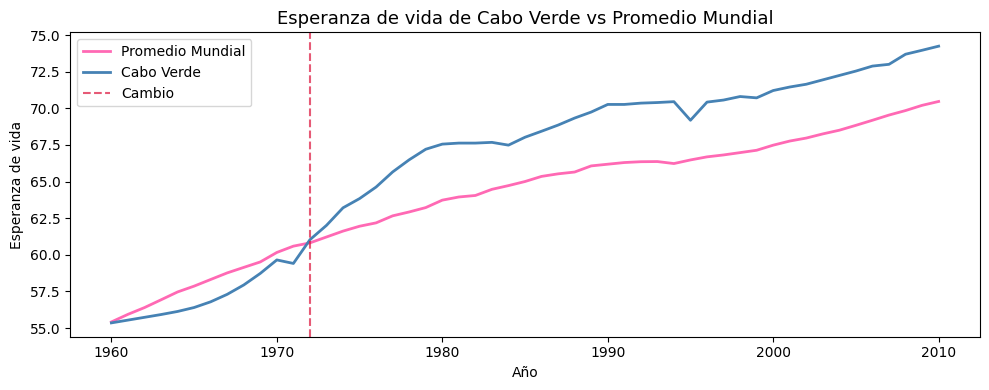

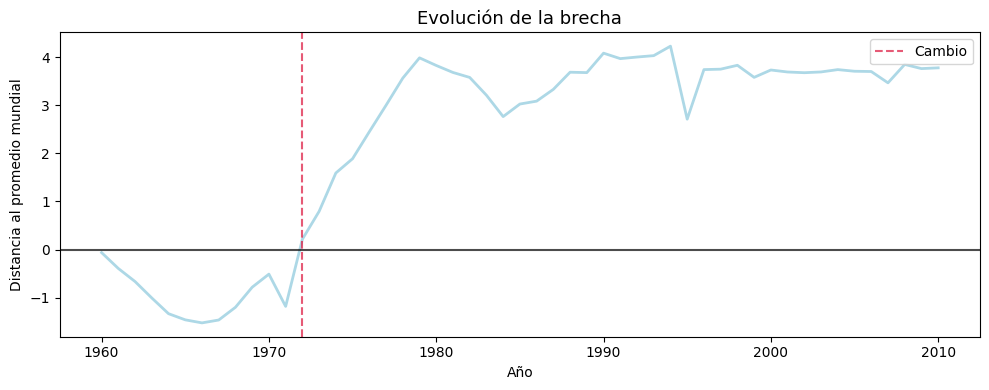

In [15]:
# ── Resultados ────────────────────────────────────────────────────────────────

# Observaciones numéricas
print('------------ Observaciones de la brecha ---------------------------------')
print(' ')
print("La brecha promedio en todo el período temporal analizado es", round(np.mean(brecha_CV),4))
print("El valor más lejano DEBAJO de la brecha fue", round(brecha_CV.min(),4))
print("El valor más lejano ENCIMA de la brecha fue", round(brecha_CV.max(),4))
print('-------------------------------------------------------------------------')

#Gráficos

# Generación de gráfico y tamaño
fig, ax = plt.subplots(figsize=(10, 4))
# Plot con la evolución del promedio mundial de la esperanza de vida
ax.plot(gap_CV['year'], gap_CV['esperanza_promedio'], color='hotpink', linewidth=2, label="Promedio Mundial")
# Plot con la evolución de la esperanza de vida de Cabo Verde
ax.plot(gap_CV['year'], gap_CV['life_expectancy'], color='steelblue', linewidth=2, label="Cabo Verde")
# Recta para señalar la superación del promedio mundial
ax.axvline(año_cambio, color='crimson', linestyle='--', alpha=0.7, label='Cambio')
# Títulos
ax.set_title('Esperanza de vida de Cabo Verde vs Promedio Mundial', fontsize=13)
ax.set_xlabel('Año')
ax.legend()
ax.set_ylabel('Esperanza de vida')
plt.tight_layout()

# Generación de gráfico y tamaño
fig, ax = plt.subplots(figsize=(10, 4))
# Plot de la brecha
ax.plot(gap_CV['year'], gap_CV['brecha'], color='lightblue', linewidth=2)
# Linea horizontal donde promedio mundial = Cabo Verde
ax.axhline(0, color='black', linestyle='-', alpha=0.7)
# Recta para señalar la superación del promedio mundial
ax.axvline(año_cambio, color='crimson', linestyle='--', alpha=0.7, label='Cambio')
# Títulos
ax.set_title('Evolución de la brecha', fontsize=13)
ax.set_xlabel('Año')
ax.legend()
ax.set_ylabel('Distancia al promedio mundial')
plt.tight_layout()
plt.show()

Se puede observar que para el caso de Cabo Verde la esperanza de vida promedio empezó el período analizado alejándose del promedio mundial, siendo el valor más extremo en este período de aproximadamente un año y medio menos de vida.

Sin embargo, luego empezó a converger hacia el promedio mundial, superándolo en el año 1972. La esperanza de vida siguió subiendo y la brecha se estabilizó en aproximadamente 4 años más de vida que el promedio mundial hasta el final del período analizado.

---
### Pregunta B - Atipicidad

Para esta pregunta se tomó como continente la region a la que pertenece Cabo Verde en el dataset, *Sub_saharan_africa* (África Subsahariana). Si bien se deberían incluir también los países de la región norte de África, se optó por no hacerlo ya que en el dataset estos están agrupados junto con países del Medio Oriente. Los países del Medio Oriente tienen características muy distintas a los de África por lo que incluir ambas regiones en la comparación hubiera sesgado el análisis.


Se procederá a continuación a analizar la brecha entre los valores de Cabo Verde y el promedio continental de algunas de las variables restantes del dataset.

In [16]:
# ── Análisis de la base ───────────────────────────────────────────────────────

# Filtro para seleccionar paises africanos
paises_africanos = ((gap['world_region'] == 'sub_saharan_africa'))

# Generación de nuevo dataset filtrado (solo datos de paises africanos)
gap_africa = gap[paises_africanos].copy()

#  Generación y renombre de promedio continental de variables
esperanza_media_africa = gap_africa.groupby('year')['life_expectancy'].mean()
esperanza_media_africa = esperanza_media_africa.rename("esperanza_promedio_africa")
hijos_por_mujer_africa = gap_africa.groupby('year')['children_per_woman'].mean()
hijos_por_mujer_africa = hijos_por_mujer_africa.rename("promedio_de_hijos")
ingreso_per_cap_africa = gap_africa.groupby('year')['income_per_person'].mean()
ingreso_per_cap_africa = ingreso_per_cap_africa.rename("ingreso_per_cap_promedio")
mortalidad_infantil_africa = gap_africa.groupby('year')['child_mortality'].mean()
mortalidad_infantil_africa = mortalidad_infantil_africa.rename("mortalidad_infantil_promedio")
gap_africa['life_expectancy_female'] = pd.to_numeric(gap_africa['life_expectancy_female'])
esperanza_mujer_africa = gap_africa.groupby('year')['life_expectancy_female'].mean()
esperanza_mujer_africa = esperanza_mujer_africa.rename("esperanza_mujeres_promedio")

# Generación de lista de variables de promedio
variables = [esperanza_media_africa, hijos_por_mujer_africa, ingreso_per_cap_africa,
             mortalidad_infantil_africa, esperanza_mujer_africa]

# Loop para unir cada serie del promedio continental de las variables con el
# dataset original. La unión se hace vía 'year' por lo que cada año de cada
# país tiene el promedio continental correspondiente
for i in variables:
  gap_africa = pd.merge(gap_africa, i, on=['year'], how='inner')

# Generación de nueva columna para la brecha de cada país en cada año
gap_africa['brecha_esp_africa'] = gap_africa['life_expectancy']-gap_africa['esperanza_promedio_africa']
gap_africa['brecha_hijos_africa'] = gap_africa['children_per_woman']-gap_africa['promedio_de_hijos']
gap_africa['brecha_ingreso_africa'] = gap_africa['income_per_person']-gap_africa['ingreso_per_cap_promedio']
gap_africa['brecha_mortalidad_africa'] = gap_africa['child_mortality']-gap_africa['mortalidad_infantil_promedio']
gap_africa['brecha_esp_mujer_africa'] = gap_africa['life_expectancy_female']-gap_africa['esperanza_mujeres_promedio']

# Filtro para seleccionar Cabo Verde
pais_elegido_africa = (gap_africa['country'] == 'Cape Verde')
# Generación de nuevo dataset filtrado (solo datos de Cabo Verde)
gap_CV_africa = gap_africa[pais_elegido_africa]

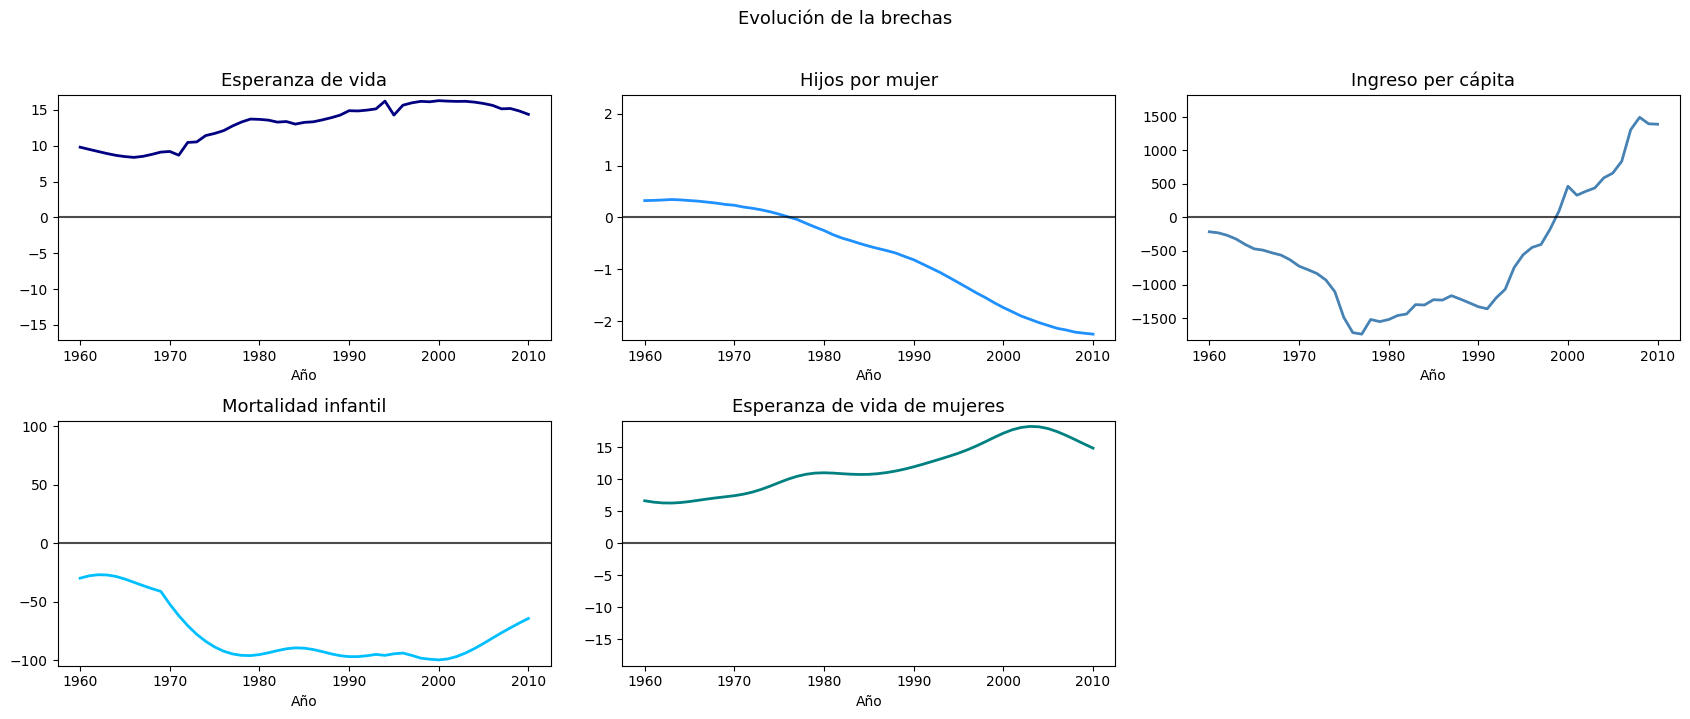

In [17]:
# ── Resultados ────────────────────────────────────────────────────────────────

# Generación de listas de brechas, nombres de variables y colores para gráficos
brechas = ['brecha_esp_africa', 'brecha_hijos_africa', 'brecha_ingreso_africa',
           'brecha_mortalidad_africa', 'brecha_esp_mujer_africa']
nombres = ['Esperanza de vida', 'Hijos por mujer', 'Ingreso per cápita',
           'Mortalidad infantil', 'Esperanza de vida de mujeres']
colores = ['navy', 'dodgerblue', 'steelblue', 'deepskyblue', 'teal']

# Configuración de grilla y tamaño para los gráficos
fig, axes = plt.subplots(2, 3, figsize=(17, 7))
axes_flat = axes.flatten()

# Loop para generar los gráficos para cada brecha de cada variable
for b, ax, n, c in zip(brechas, axes_flat, nombres, colores):
  # Plot de la brecha
  ax.plot(gap_CV['year'], gap_CV_africa[b], linewidth=2, color=c)
  # Linea horizontal donde promedio continental = Cabo Verde
  ax.axhline(0, color='black', linestyle='-', alpha=0.7)
  # Cálculo de valor máximo de la brecha para esa variable
  max_val = abs(gap_CV_africa[b]).max()
  # Límites de los ejes según el máximo
  ax.set_ylim(-max_val*1.05, max_val*1.05)
  # Títulos
  ax.set_title(f'{n}', fontsize=13)
  ax.set_xlabel('Año')

fig.suptitle('Evolución de la brechas', fontsize=13, y=1.02)
axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

Para la esperanza de vida, se puede observar la misma forma que en la pregunta A (con el salto en 1972) con la diferencia que siempre fue mayor que el promedio continental. Por lo tanto, este fue un salto significativo en términos de la media mundial pero en términos del continente africano fue una continuación de la tendencia de Cabo Verde a estar por encima del promedio. Lo mismo sucede con la esperanza de vida de las mujeres.

Tanto para la cantidad de hijos por mujer, la mortalidad infantil como el ingreso per cápita parece haber un cambio durante la década de 1970. Se tomará a continuación el caso del ingreso per cápita para un mayor análisis.

In [33]:
datos_ingresos = gap_CV_africa[['year', 'brecha_ingreso_africa']]

cambio = (datos_ingresos['brecha_ingreso_africa'] > 0 )
año_cambio = datos_ingresos[cambio]['year'].min()

año_debajo = datos_ingresos.sort_values(by='brecha_ingreso_africa')['year'].iloc[0]
año_encima = datos_ingresos.sort_values(by='brecha_ingreso_africa')['year'].iloc[-1]

# Observaciones numéricas
print('------ Observaciones de la brecha del ingreso per cápita --------------')
print(' ')
print("La brecha promedio en todo el período temporal analizado es", round(np.mean(datos_ingresos['brecha_ingreso_africa']),4))
print("El valor más lejano DEBAJO de la brecha fue", round(datos_ingresos['brecha_ingreso_africa'].min(),4), "en", año_debajo)
print("El valor más lejano ENCIMA de la brecha fue", round(datos_ingresos['brecha_ingreso_africa'].max(),4), "en", año_encima)
print("El año en que el el ingreso per cápita superó el promedio continental fue", año_cambio)
print('-------------------------------------------------------------------------')

------ Observaciones de la brecha del ingreso per cápita --------------
 
La brecha promedio en todo el período temporal analizado es -540.6013
El valor más lejano DEBAJO de la brecha fue -1739.4167 en 1977
El valor más lejano ENCIMA de la brecha fue 1491.625 en 2008
El año en que el el ingreso per cápita superó el promedio continental fue 1999
-------------------------------------------------------------------------


Investigando un poco acerca de la historia de Cabo Verde, el African Studies Center de UCLA explica que las islas fueron colonizadas por Portugal en el siglo XV y recien obtuvieron su independencia en 1975. Esto parece alinearse con las observaciones realizadas de la brecha del ingreso per cápita: alcanzó su mínimo en 1977, dos años despúes del proceso de independencia, y luego empezó a recuperarse.

La fuente consultada también explica que durante la segunda mitad del siglo 20 hubo varías sequías y emigración. El efecto de esto sobre el ingreso per cápita puede ser ambiguo ya que el ingreso disminuye pero también lo hace la población.

Por último, la fuente menciona que la primera elección en la que participaron varios partidos políticos (y no uno solo) fue en 1990. Se debería buscar más información pero uno podría pensar que este cambio en el sistema político tal vez podría relacionarse con la convergencia hacia el promedio continental que inicia en 1990 y culmina con la superación del promedio en 1999.

*Fuente: https://www.international.ucla.edu/asc/countries/96724#*

## Conclusión PARTE 3:

Este análisis de la base de datos de Gapminder permitió detectar trayectorias de desarrollo versus el promedio mundial pero también versus el promedio continental. La realización de gráficos funcionó como punto de partida para investigaciones acerca de la historia y economía del país elegido. Si bien se necesita una investigación más profunda, la observación de gráficos puede servir como indicio.



---

